<h2 style='color:blue' align='center'>KNN Classifier Using Digits Dataset</h2>

In [6]:
# Import libraries
import pandas as pd
from sklearn.datasets import load_digits

# Load dataset
digits = load_digits()

# Create dataframe
df = pd.DataFrame(digits.data)

# Add target column
df['target'] = digits.target

# Display first 5 rows
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [7]:
# Input and Output

X = df.drop('target', axis='columns')
y = df.target

In [8]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [9]:
# Try different K values

from sklearn.neighbors import KNeighborsClassifier

k_values = [1,3,5,7,9]

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    print("K =", k, "Accuracy =", score)

K = 1 Accuracy = 0.9916666666666667
K = 3 Accuracy = 0.9944444444444445
K = 5 Accuracy = 0.9944444444444445
K = 7 Accuracy = 0.9972222222222222
K = 9 Accuracy = 0.9972222222222222


In [10]:
# Final model with best K value

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [11]:
# Accuracy of final model

print(model.score(X_test, y_test))

0.9944444444444445


In [12]:
# Predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[1 5 0 7 1 0 6 1 5 4]


In [13]:
# Actual values

print(y_test[:10].values)

[1 5 0 7 1 0 6 1 5 4]


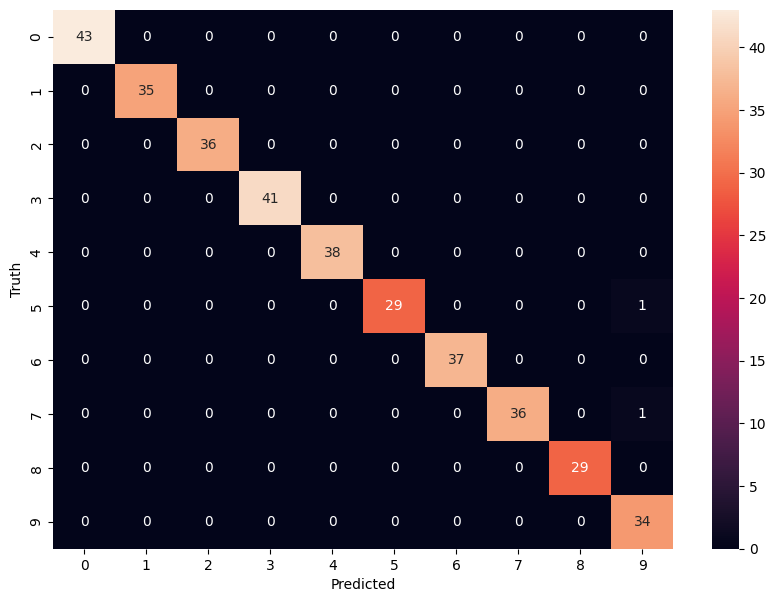

In [14]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.show()

In [15]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        36
           3       1.00      1.00      1.00        41
           4       1.00      1.00      1.00        38
           5       1.00      0.97      0.98        30
           6       1.00      1.00      1.00        37
           7       1.00      0.97      0.99        37
           8       1.00      1.00      1.00        29
           9       0.94      1.00      0.97        34

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

